# Stage 1 RQ2, AAA

## 1. Preprocessing

In [1]:
import subprocess, sys

# install any missing packages (spaces in path workaround)
packages = ["dowhy", "econml", "causal-learn", "pandas", "numpy", "networkx"]
for pkg in packages:
    subprocess.run([sys.executable, "-m", "pip", "install", pkg], check=False)

import pandas as pd
import numpy as np
import networkx as nx
from dowhy import CausalModel
from econml.dml import CausalForestDML

pd.set_option("display.max_columns", None)

# load AAA's raw merged module data
df = pd.read_csv(r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\AAA.csv")
df.shape

In [3]:
# Cell 2: Select relevant columns and identify click columns

demographics = ['gender', 'region', 'highest_education', 'imd_band', 'age_band',
                'disability', 'studied_credits', 'num_of_prev_attempts']
score_cols = ['ass_1_score', 'ass_2_score', 'ass_3_score', 'ass_4_score', 'ass_5_score']
click_cols = [c for c in df.columns if c.startswith('clicks_')]

df_sel = df[demographics + score_cols + click_cols + ['final_result']].copy()
df_sel.shape

In [5]:
# Cell 3: Handle missing values

# assessment scores: NaN -> -1 (non-submission)
df_sel[score_cols] = df_sel[score_cols].fillna(-1)

# individual click columns: NaN -> 0 (no activity)
df_sel[click_cols] = df_sel[click_cols].fillna(0)

# imd_band: fix the '10-20' missing-% bug, then mode-impute any remaining NaN
df_sel['imd_band'] = df_sel['imd_band'].replace('10-20', '10-20%')
imd_mode = df_sel['imd_band'].mode()[0]
df_sel['imd_band'] = df_sel['imd_band'].fillna(imd_mode)

print(df_sel.isnull().sum().sum())  # should be 0

0


In [7]:
# Cell 4: Encodings

final_result_map = {'Withdrawn': 0, 'Fail': 1, 'Pass': 2, 'Distinction': 3}
education_map = {
    'No Formal quals': 0, 'Lower Than A Level': 1, 'A Level or Equivalent': 2,
    'HE Qualification': 3, 'Post Graduate Qualification': 4
}
imd_map = {
    '0-10%': 0, '10-20%': 1, '20-30%': 2, '30-40%': 3, '40-50%': 4,
    '50-60%': 5, '60-70%': 6, '70-80%': 7, '80-90%': 8, '90-100%': 9
}
age_band_map = {'0-35': 0, '35-55': 1, '55<=': 2}

df_sel['final_result'] = df_sel['final_result'].map(final_result_map)
df_sel['highest_education'] = df_sel['highest_education'].map(education_map)
df_sel['imd_band'] = df_sel['imd_band'].map(imd_map)
df_sel['age_band'] = df_sel['age_band'].map(age_band_map)

# binary encodings
df_sel['gender'] = df_sel['gender'].map({'M': 0, 'F': 1})
df_sel['disability'] = df_sel['disability'].map({'N': 0, 'Y': 1})

# region: label encoding (no inherent order)
df_sel['region'] = df_sel['region'].astype('category').cat.codes

print(df_sel.isnull().sum().sum())  # should still be 0
df_sel.dtypes

0


gender                    int64
region                     int8
highest_education         int64
imd_band                  int64
age_band                  int64
disability                int64
studied_credits           int64
num_of_prev_attempts      int64
ass_1_score             float64
ass_2_score             float64
ass_3_score             float64
ass_4_score             float64
ass_5_score             float64
clicks_dataplus         float64
clicks_forumng          float64
clicks_glossary         float64
clicks_homepage         float64
clicks_oucollaborate    float64
clicks_oucontent        float64
clicks_resource         float64
clicks_subpage          float64
clicks_url              float64
final_result              int64
dtype: object

In [9]:
# Cell 5: Build total_clicks and quartile-bin assessments + total_clicks
# (matches the RQ1 DAG variable set -- individual clicks collapsed to one composite)

df_sel['total_clicks'] = df_sel[click_cols].sum(axis=1)
df_sel = df_sel.drop(columns=click_cols)

bin_cols = score_cols + ['total_clicks']
for col in bin_cols:
    df_sel[col] = pd.qcut(df_sel[col], q=4, labels=False, duplicates='drop')

df_sel[bin_cols].nunique()

ass_1_score     4
ass_2_score     4
ass_3_score     4
ass_4_score     4
ass_5_score     4
total_clicks    4
dtype: int64

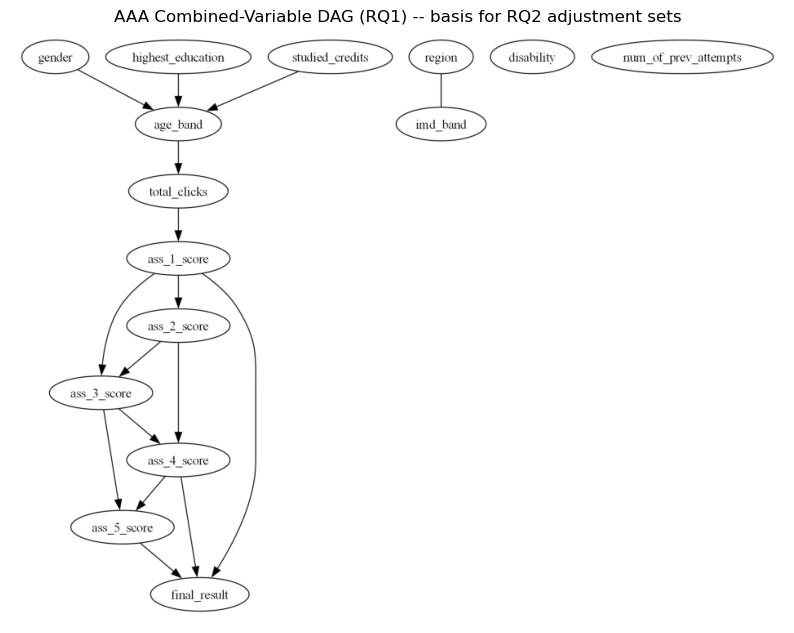

In [11]:
# Cell 6: Display AAA's finalized causal DAG (from RQ1) for reference in this notebook

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

dag_img = mpimg.imread(r"C:\Users\Disha Sharma\Desktop\Paper_1\AAA_DAG.png")  # update to your actual saved path from RQ1

plt.figure(figsize=(10, 10))
plt.imshow(dag_img)
plt.axis('off')
plt.title("AAA Combined-Variable DAG (RQ1) -- basis for RQ2 adjustment sets")
plt.show()

## 2. Adjustment set derivation

In [13]:
# Cell 7: Define treatments and their adjustment sets (from AAA's RQ1 DAG)

treatments = {
    'gender': [],
    'highest_education': [],
    'studied_credits': [],
    'age_band': ['gender', 'highest_education', 'studied_credits'],
    'total_clicks': ['age_band'],
    'ass_1_score': ['total_clicks'],
    'ass_2_score': ['ass_1_score'],
    'ass_3_score': ['ass_1_score', 'ass_2_score'],
    'ass_4_score': ['ass_2_score', 'ass_3_score'],
    'ass_5_score': ['ass_3_score', 'ass_4_score'],
}

outcome = 'final_result'
results = []

## 3. Average Treatment Effect (ATE) estimation

In [19]:
# Cell 8 : loop -- identify, estimate, store results, confidence intervals

results = []  

for treatment, common_causes in treatments.items():
    model = CausalModel(
        data=df_sel,
        treatment=treatment,
        outcome=outcome,
        common_causes=common_causes
    )
    
    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
    estimate = model.estimate_effect(
        identified_estimand,
        method_name="backdoor.linear_regression",
        confidence_intervals=True
    )
    
    ci = estimate.get_confidence_intervals()
    
    results.append({
        'treatment': treatment,
        'adjustment_set': ', '.join(common_causes) if common_causes else '(none -- root)',
        'ate': estimate.value,
        'ci_lower': ci[0][0],
        'ci_upper': ci[0][1]
    })
    
    print(f"{treatment}: ATE = {estimate.value:.4f}, CI = [{ci[0][0]:.4f}, {ci[0][1]:.4f}]")

results_df = pd.DataFrame(results)
results_df

gender: ATE = -0.1893, CI = [-0.3099, -0.0687]
highest_education: ATE = 0.0139, CI = [-0.0708, 0.0985]
studied_credits: ATE = -0.0038, CI = [-0.0051, -0.0025]
age_band: ATE = 0.0005, CI = [-0.0986, 0.0997]
total_clicks: ATE = 0.3303, CI = [0.2792, 0.3814]
ass_1_score: ATE = 0.1569, CI = [0.1038, 0.2100]
ass_2_score: ATE = 0.3271, CI = [0.2696, 0.3846]
ass_3_score: ATE = 0.3937, CI = [0.3301, 0.4572]
ass_4_score: ATE = 0.4274, CI = [0.3643, 0.4904]
ass_5_score: ATE = 0.3190, CI = [0.2575, 0.3804]


,treatment,adjustment_set,ate,ci_lower,ci_upper
0,gender,(none -- root),-0.189278,-0.309882,-0.068673
1,highest_education,(none -- root),0.013853,-0.070791,0.098497
2,studied_credits,(none -- root),-0.003800,-0.005053,-0.002546
3,age_band,"gender, highest_education, studied_credits",0.000508,-0.098634,0.099651
4,total_clicks,age_band,0.330291,0.279189,0.381393
5,ass_1_score,total_clicks,0.156881,0.103793,0.209968
6,ass_2_score,ass_1_score,0.327107,0.269639,0.384575
7,ass_3_score,"ass_1_score, ass_2_score",0.393657,0.330072,0.457242
8,ass_4_score,"ass_2_score, ass_3_score",0.427357,0.364289,0.490424
9,ass_5_score,"ass_3_score, ass_4_score",0.318975,0.257512,0.380438


## 4. Refutation testing

In [21]:
# Cell 9: Refutation -- placebo treatment + random common cause, all 10 treatments

refutation_results = []

for treatment, common_causes in treatments.items():
    model = CausalModel(
        data=df_sel,
        treatment=treatment,
        outcome=outcome,
        common_causes=common_causes
    )
    
    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
    estimate = model.estimate_effect(
        identified_estimand,
        method_name="backdoor.linear_regression"
    )
    
    placebo_refuter = model.refute_estimate(
        identified_estimand, estimate,
        method_name="placebo_treatment_refuter",
        placebo_type="permute"
    )
    
    random_cause_refuter = model.refute_estimate(
        identified_estimand, estimate,
        method_name="random_common_cause"
    )
    
    refutation_results.append({
        'treatment': treatment,
        'original_ate': estimate.value,
        'placebo_new_effect': placebo_refuter.new_effect,
        'placebo_p_value': placebo_refuter.refutation_result.get('p_value', None) if hasattr(placebo_refuter, 'refutation_result') else None,
        'random_cause_new_effect': random_cause_refuter.new_effect,
    })
    
    print(f"{treatment}:")
    print(f"  Placebo -> new effect ≈ {placebo_refuter.new_effect:.4f} (should be ≈ 0)")
    print(f"  Random common cause -> new effect ≈ {random_cause_refuter.new_effect:.4f} (should ≈ original {estimate.value:.4f})")
    print()

refutation_df = pd.DataFrame(refutation_results)
refutation_df

gender:
  Placebo -> new effect ≈ -0.0002 (should be ≈ 0)
  Random common cause -> new effect ≈ -0.1892 (should ≈ original -0.1893)

highest_education:
  Placebo -> new effect ≈ -0.0008 (should be ≈ 0)
  Random common cause -> new effect ≈ 0.0139 (should ≈ original 0.0139)

studied_credits:
  Placebo -> new effect ≈ -0.0000 (should be ≈ 0)
  Random common cause -> new effect ≈ -0.0038 (should ≈ original -0.0038)

age_band:
  Placebo -> new effect ≈ -0.0051 (should be ≈ 0)
  Random common cause -> new effect ≈ 0.0004 (should ≈ original 0.0005)

total_clicks:
  Placebo -> new effect ≈ 0.0026 (should be ≈ 0)
  Random common cause -> new effect ≈ 0.3303 (should ≈ original 0.3303)

ass_1_score:
  Placebo -> new effect ≈ -0.0024 (should be ≈ 0)
  Random common cause -> new effect ≈ 0.1572 (should ≈ original 0.1569)

ass_2_score:
  Placebo -> new effect ≈ -0.0032 (should be ≈ 0)
  Random common cause -> new effect ≈ 0.3270 (should ≈ original 0.3271)

ass_3_score:
  Placebo -> new effect ≈ 0.0

,treatment,original_ate,placebo_new_effect,placebo_p_value,random_cause_new_effect
0,gender,-0.189278,-0.000186,0.96,-0.189175
1,highest_education,0.013853,-0.000778,0.92,0.013948
2,studied_credits,-0.003800,-0.000029,0.98,-0.003801
3,age_band,0.000508,-0.005110,0.88,0.000412
4,total_clicks,0.330291,0.002555,0.86,0.330283
5,ass_1_score,0.156881,-0.002353,0.92,0.157177
6,ass_2_score,0.327107,-0.003216,0.90,0.327014
7,ass_3_score,0.393657,0.001896,1.00,0.393677
8,ass_4_score,0.427357,0.002646,0.98,0.427270
9,ass_5_score,0.318975,0.001463,0.88,0.319039


## 5. Heterogeneous Treatment Effect (CATE) estimation

In [23]:
# Cell 10: CATE setup -- total_clicks -> final_result, X = age_band vs X = imd_band

from econml.dml import CausalForestDML
from econml.cate_interpreter import SingleTreeCateInterpreter, SingleTreePolicyInterpreter

Y = df_sel['final_result']
T = df_sel['total_clicks']

# --- Run A: X = age_band (W empty, since age_band leaves the confounder set to become X) ---
X_age = df_sel[['age_band']]

est_age = CausalForestDML(random_state=42)
est_age.fit(Y, T, X=X_age, W=None)
cate_age = est_age.effect(X_age)
print("age_band CATE range:", cate_age.min(), "to", cate_age.max())

# --- Run B: X = imd_band (W = age_band, since age_band stays a confounder here) ---
X_imd = df_sel[['imd_band']]
W_imd = df_sel[['age_band']]

est_imd = CausalForestDML(random_state=42)
est_imd.fit(Y, T, X=X_imd, W=W_imd)
cate_imd = est_imd.effect(X_imd)
print("imd_band CATE range:", cate_imd.min(), "to", cate_imd.max())

age_band CATE range: 0.2697130194566315 to 0.3564791088859623
imd_band CATE range: 0.18712854449123414 to 0.39710618517788365


## 6. Policy interpretation

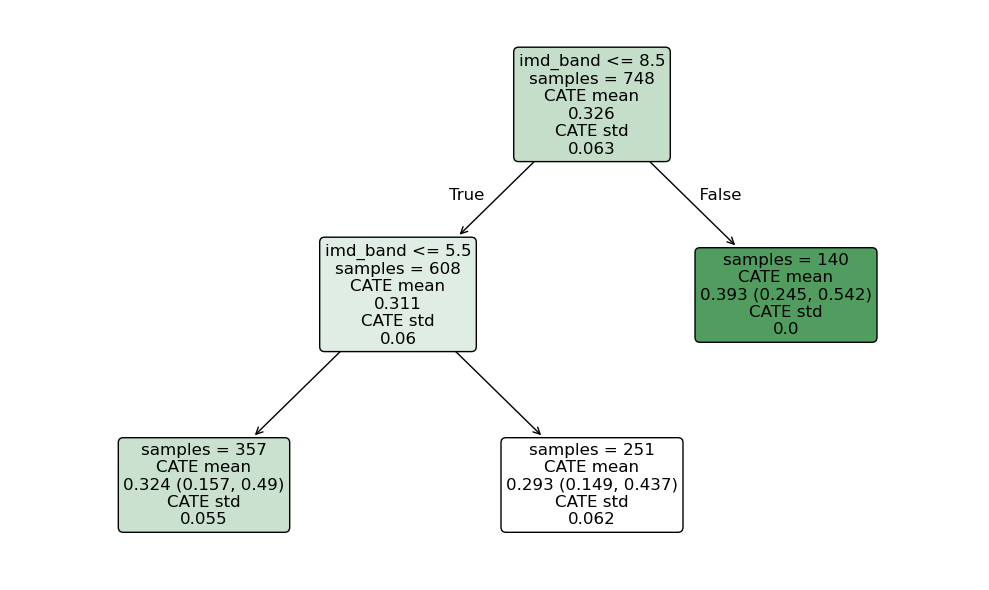

In [49]:
# Cell 11: SingleTreeCateInterpreter -- where does the effect vary most?

intrp_age = SingleTreeCateInterpreter(include_model_uncertainty=True, max_depth=2)
intrp_age.interpret(est_age, X_age)

intrp_imd = SingleTreeCateInterpreter(include_model_uncertainty=True, max_depth=2)
intrp_imd.interpret(est_imd, X_imd)

plt.figure(figsize=(10, 6))
intrp_imd.plot(feature_names=['imd_band'], fontsize=12)
plt.tight_layout()
plt.show()

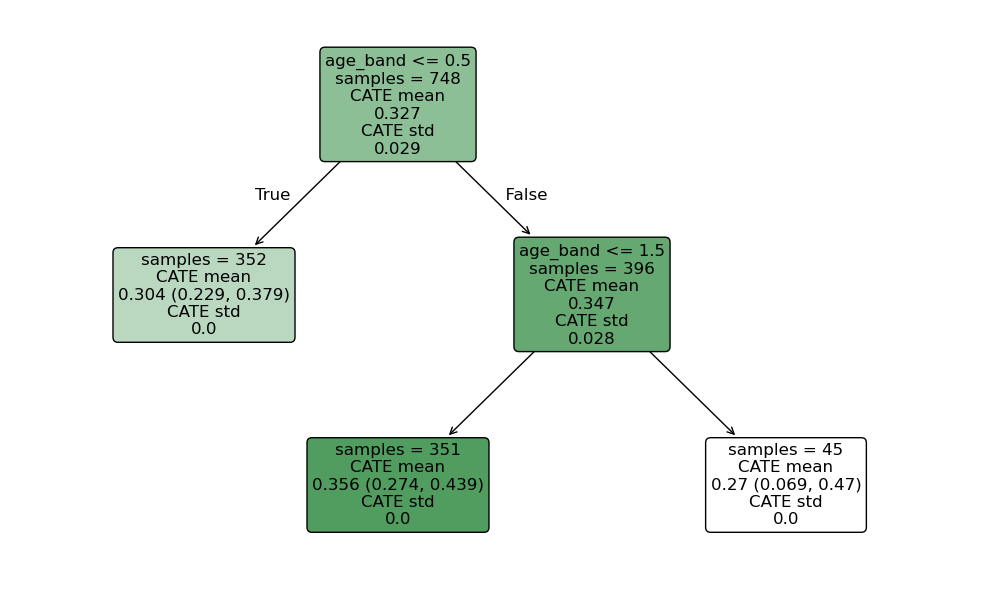

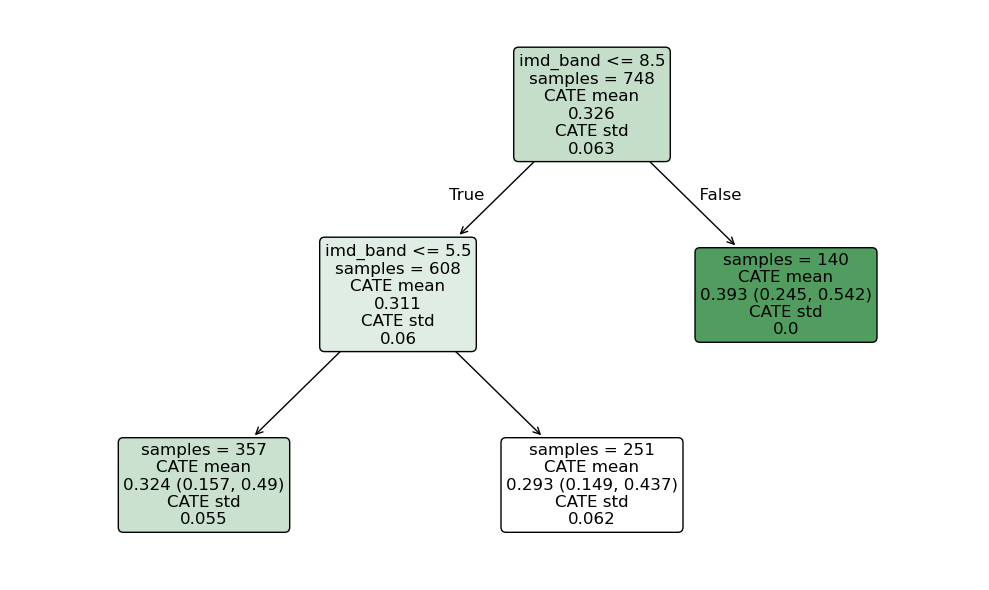

In [51]:
intrp_age = SingleTreeCateInterpreter(include_model_uncertainty=True, max_depth=2)
intrp_age.interpret(est_age, X_age)

intrp_imd = SingleTreeCateInterpreter(include_model_uncertainty=True, max_depth=2)
intrp_imd.interpret(est_imd, X_imd)

plt.figure(figsize=(10, 6))
intrp_age.plot(feature_names=X_age.columns.tolist(), fontsize=12)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
intrp_imd.plot(feature_names=X_imd.columns.tolist(), fontsize=12)
plt.tight_layout()
plt.show()

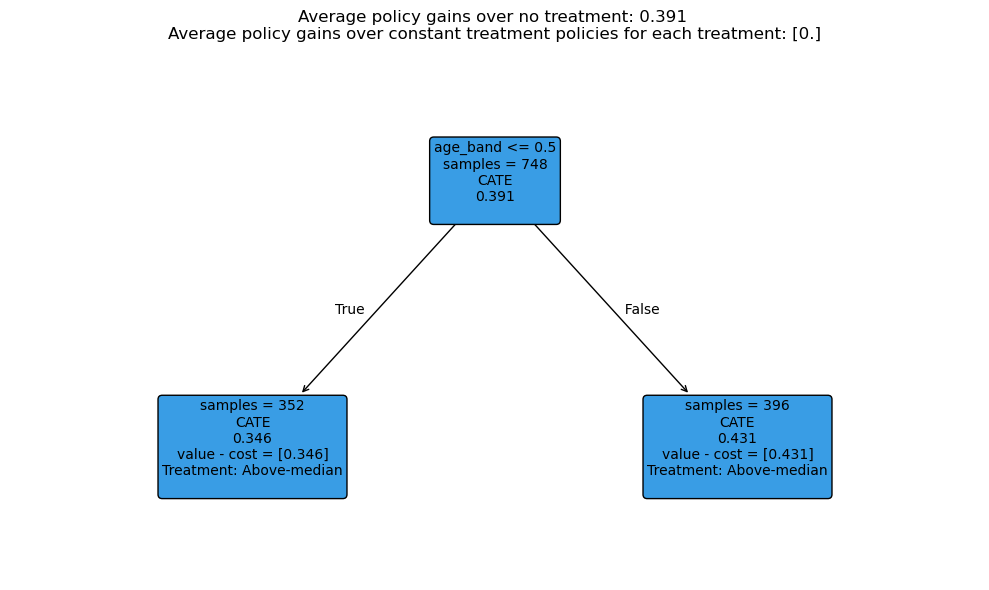

In [37]:
# Cell 12: SingleTreePolicyInterpreter -- binarize total_clicks first (median split)

median_clicks = df_sel['total_clicks'].median()
T_binary = (df_sel['total_clicks'] > median_clicks).astype(int)

est_age_policy = CausalForestDML(random_state=42)
est_age_policy.fit(Y, T_binary, X=X_age, W=None)

intrp_policy_age = SingleTreePolicyInterpreter(risk_level=0.05, max_depth=2)
intrp_policy_age.interpret(est_age_policy, X_age, sample_treatment_costs=0.0)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
intrp_policy_age.plot(
    feature_names=['age_band'],
    treatment_names=['Below-median', 'Above-median'],
    fontsize=10
)
plt.tight_layout()
plt.show()

## 7. Feature-contribution table

In [53]:
# Cell 13: CATE summary -- age_band and imd_band as moderators, all 10 treatments

Y = df_sel['final_result']
cate_summary = []

for treatment, common_causes in treatments.items():
    T = df_sel[treatment]
    
    # --- X = age_band (skip if age_band is the treatment itself) ---
    if treatment != 'age_band':
        W_age = [c for c in common_causes if c != 'age_band']
        W_age_data = df_sel[W_age] if W_age else None
        X_age = df_sel[['age_band']]
        
        est_age = CausalForestDML(random_state=42)
        est_age.fit(Y, T, X=X_age, W=W_age_data)
        cate_age = est_age.effect(X_age)
        
        cate_summary.append({
            'treatment': treatment, 'moderator': 'age_band',
            'cate_mean': cate_age.mean(), 'cate_min': cate_age.min(),
            'cate_max': cate_age.max(), 'cate_std': cate_age.std()
        })
    
    # --- X = imd_band ---
    W_imd_data = df_sel[common_causes] if common_causes else None
    X_imd = df_sel[['imd_band']]
    
    est_imd = CausalForestDML(random_state=42)
    est_imd.fit(Y, T, X=X_imd, W=W_imd_data)
    cate_imd = est_imd.effect(X_imd)
    
    cate_summary.append({
        'treatment': treatment, 'moderator': 'imd_band',
        'cate_mean': cate_imd.mean(), 'cate_min': cate_imd.min(),
        'cate_max': cate_imd.max(), 'cate_std': cate_imd.std()
    })
    
    print(f"{treatment} done")

cate_summary_df = pd.DataFrame(cate_summary)
cate_summary_df

gender done
highest_education done
studied_credits done
age_band done
total_clicks done
ass_1_score done
ass_2_score done
ass_3_score done
ass_4_score done
ass_5_score done


,treatment,moderator,cate_mean,cate_min,cate_max,cate_std
0,gender,age_band,-0.256454,-1.444237,-0.169872,0.300689
1,gender,imd_band,-0.215041,-0.526939,-0.049829,0.143726
2,highest_education,age_band,0.016741,-0.064263,0.266651,0.089209
3,highest_education,imd_band,0.005952,-0.146011,0.158208,0.087928
4,studied_credits,age_band,-0.003950,-0.005528,0.000719,0.001712
5,studied_credits,imd_band,-0.004046,-0.010182,0.000527,0.003318
6,age_band,imd_band,0.004181,-0.248685,0.417667,0.176172
7,total_clicks,age_band,0.326569,0.269713,0.356479,0.029218
8,total_clicks,imd_band,0.326458,0.187129,0.397106,0.062967
9,ass_1_score,age_band,0.153496,0.138874,0.305045,0.038639


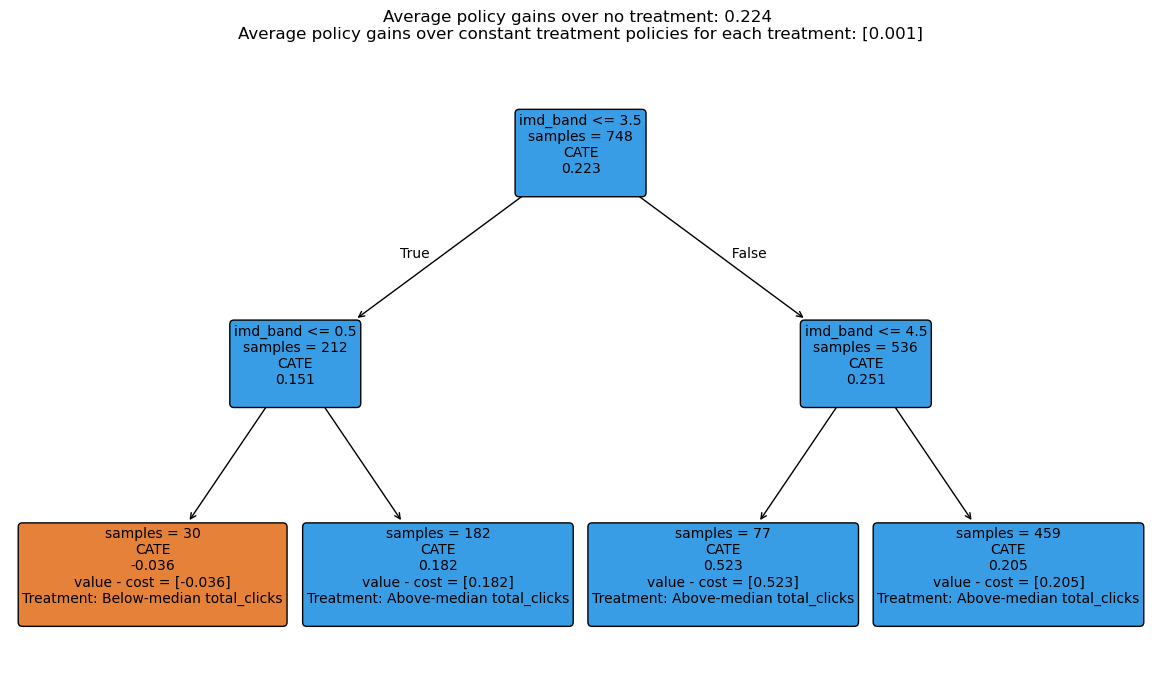

In [61]:
# Cell 14 (narrowed): SingleTreePolicyInterpreter -- total_clicks only, imd_band moderator, cost = 0

treatment = 'total_clicks'
common_causes = treatments[treatment]  # ['age_band']

T_raw = df_sel[treatment]
median_val = T_raw.median()
T_binary = (T_raw > median_val).astype(int)
labels = ['Below-median total_clicks', 'Above-median total_clicks']

W_imd_data = df_sel[common_causes]  # ['age_band']
X_imd = df_sel[['imd_band']]

est_policy = CausalForestDML(random_state=42)
est_policy.fit(Y, T_binary, X=X_imd, W=W_imd_data)

intrp_policy = SingleTreePolicyInterpreter(risk_level=0.05, max_depth=2)
intrp_policy.interpret(est_policy, X_imd, sample_treatment_costs=0.0)

plt.figure(figsize=(12, 7))
intrp_policy.plot(feature_names=['imd_band'], treatment_names=labels, fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "AAA_policy_total_clicks_imdband.png"), dpi=150, bbox_inches='tight')
plt.show()

## 8. Visual representations 

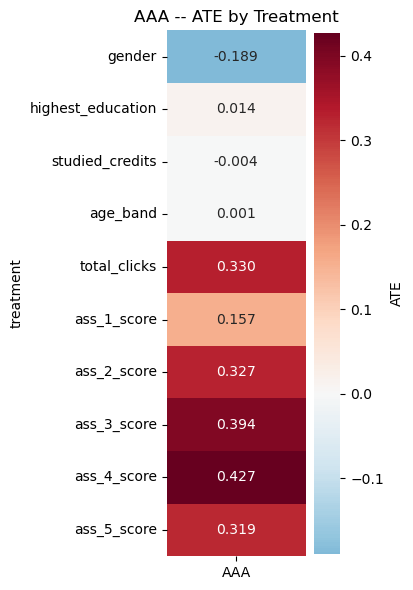

In [63]:
# Cell 15: ATE heatmap (AAA only for now -- structured for future module columns)

import seaborn as sns

heatmap_data = results_df.set_index('treatment')[['ate']].rename(columns={'ate': 'AAA'})

plt.figure(figsize=(4, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdBu_r', center=0, 
            cbar_kws={'label': 'ATE'})
plt.title('AAA -- ATE by Treatment')
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "AAA_ATE_heatmap.png"), dpi=150, bbox_inches='tight')
plt.show()

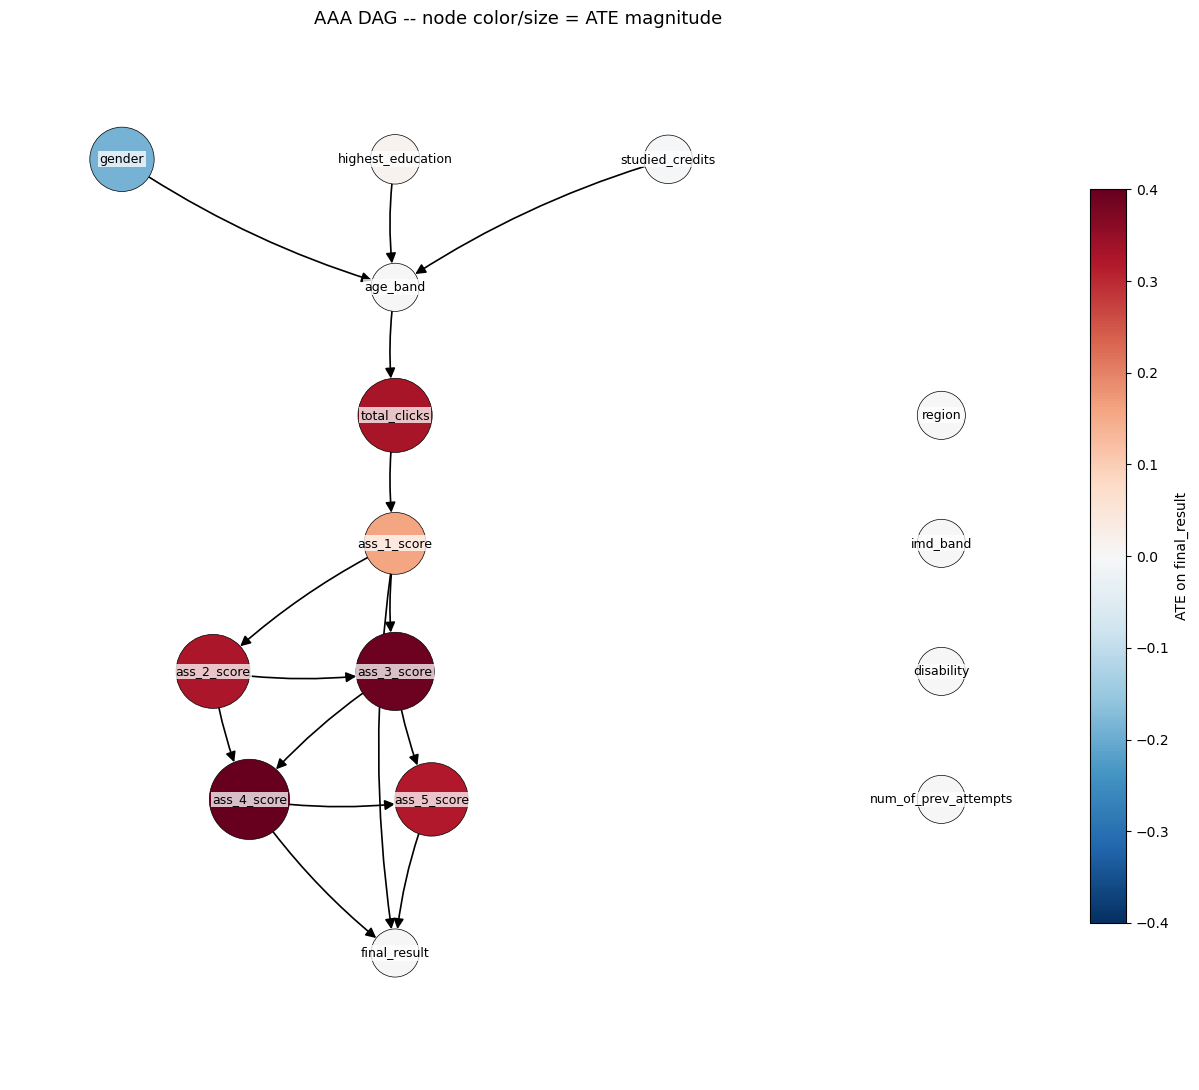

In [86]:
# Cell 16 (rebuilt): DAG with nodes colored/sized by ATE magnitude -- manual layout, publishable version

G = nx.DiGraph()
edges = [
    ('gender', 'age_band'), ('highest_education', 'age_band'), ('studied_credits', 'age_band'),
    ('age_band', 'total_clicks'), ('total_clicks', 'ass_1_score'),
    ('ass_1_score', 'ass_2_score'), ('ass_1_score', 'ass_3_score'), ('ass_1_score', 'final_result'),
    ('ass_2_score', 'ass_3_score'), ('ass_2_score', 'ass_4_score'),
    ('ass_3_score', 'ass_4_score'), ('ass_3_score', 'ass_5_score'),
    ('ass_4_score', 'ass_5_score'), ('ass_4_score', 'final_result'),
    ('ass_5_score', 'final_result'),
]
G.add_edges_from(edges)
G.add_nodes_from(['region', 'imd_band', 'disability', 'num_of_prev_attempts'])

# manual positions mirroring the original AAA DAG image's top-down cascade
pos = {
    'gender': (0, 5), 'highest_education': (1.5, 5), 'studied_credits': (3, 5),
    'age_band': (1.5, 4),
    'total_clicks': (1.5, 3),
    'ass_1_score': (1.5, 2),
    'ass_2_score': (0.5, 1), 'ass_3_score': (1.5, 1),
    'ass_4_score': (0.7, 0), 'ass_5_score': (1.7, 0),
    'final_result': (1.5, -1.2),
    'region': (4.5, 3), 'imd_band': (4.5, 2),
    'disability': (4.5, 1), 'num_of_prev_attempts': (4.5, 0),
}

ate_lookup = dict(zip(results_df['treatment'], results_df['ate']))
node_colors = [ate_lookup.get(n, 0) for n in G.nodes()]
node_sizes = [1200 + 5000 * abs(ate_lookup.get(n, 0)) for n in G.nodes()]

plt.figure(figsize=(13, 11))
nodes = nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes,
                                 cmap='RdBu_r', vmin=-0.4, vmax=0.4, edgecolors='black', linewidths=0.5)
nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=15, width=1.2,
                        connectionstyle='arc3,rad=0.08', node_size=node_sizes)
nx.draw_networkx_labels(G, pos, font_size=9,
                         bbox=dict(facecolor='white', edgecolor='none', alpha=0.75, pad=1))
plt.colorbar(nodes, label='ATE on final_result', shrink=0.7)
plt.title('AAA DAG -- node color/size = ATE magnitude', fontsize=13)
plt.axis('off')
plt.margins(0.1)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "AAA_DAG_with_ATE.png"), dpi=200, bbox_inches='tight')
plt.show()

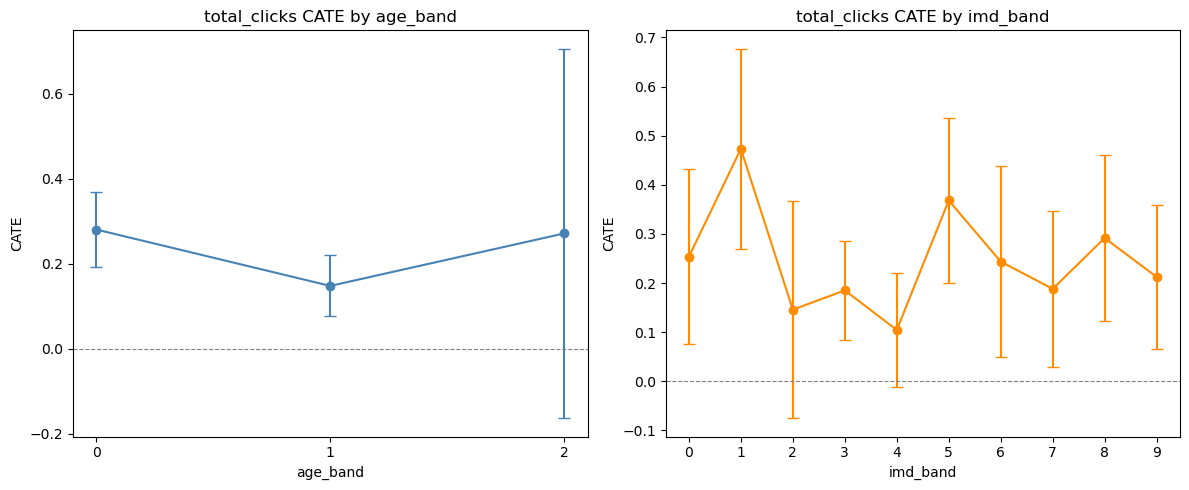

In [73]:
# Cell 17 (fixed): CATE by moderator bin, with confidence intervals -- total_clicks

age_vals = sorted(df_sel['age_band'].unique())
imd_vals = sorted(df_sel['imd_band'].unique())

# unique-bin CATE + intervals (one row per bin, not per student -- avoids duplicate overlapping points)
X_age_bins = pd.DataFrame({'age_band': age_vals})
cate_age_bins = est_age.effect(X_age_bins)
lb_age, ub_age = est_age.effect_interval(X_age_bins, alpha=0.05)

X_imd_bins = pd.DataFrame({'imd_band': imd_vals})
cate_imd_bins = est_imd.effect(X_imd_bins)
lb_imd, ub_imd = est_imd.effect_interval(X_imd_bins, alpha=0.05)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].errorbar(age_vals, cate_age_bins, 
                  yerr=[cate_age_bins - lb_age, ub_age - cate_age_bins],
                  fmt='o-', capsize=4, color='steelblue')
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[0].set_title('total_clicks CATE by age_band')
axes[0].set_xlabel('age_band')
axes[0].set_ylabel('CATE')
axes[0].set_xticks(age_vals)

axes[1].errorbar(imd_vals, cate_imd_bins,
                  yerr=[cate_imd_bins - lb_imd, ub_imd - cate_imd_bins],
                  fmt='o-', capsize=4, color='darkorange')
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_title('total_clicks CATE by imd_band')
axes[1].set_xlabel('imd_band')
axes[1].set_ylabel('CATE')
axes[1].set_xticks(imd_vals)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "AAA_CATE_distribution_total_clicks.png"), dpi=150, bbox_inches='tight')
plt.show()